# Loan Prediction (Decision Tree)

## Author, Copyright & License

**Author:** Börteçin Ege  
**Copyright © 2026 Börteçin Ege**

### Code License — MIT License

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

**Attribution:** When reusing or redistributing this code, the copyright and MIT License notice above must be retained.



### 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42

### 2. Daten hochladen (mit Error-Handling)

In [2]:
def load_data(path: str | Path) -> pd.DataFrame:
    """Lädt den Loan-Datensatz als DataFrame.

    Args:
        path: Pfad zur CSV-Datei (als str oder Path).

    Returns:
        Das eingelesene DataFrame.

    Raises:
        FileNotFoundError: Wenn die Datei nicht existiert.
        ValueError: Bei leerer / nicht parsebarer Datei oder 0 Zeilen.
    """
    path = Path(path)
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        raise FileNotFoundError(f'Datei nicht gefunden: {path}')
    except pd.errors.EmptyDataError:
        raise ValueError('Datei ist leer!')
    except pd.errors.ParserError as e:          # korrekt: ParserError (mit r)
        raise ValueError(f'.csv konnte nicht geparst werden: {e}') from e

    if df.empty:                                # Leerpruefung NACH dem Einlesen
        raise ValueError('Dataset enthält keine Zeilen!')
    return df

In [3]:
load_data.__doc__

'Lädt den Loan-Datensatz als DataFrame.\n\nArgs:\n    path: Pfad zur CSV-Datei (als str oder Path).\n\nReturns:\n    Das eingelesene DataFrame.\n\nRaises:\n    FileNotFoundError: Wenn die Datei nicht existiert.\n    ValueError: Bei leerer / nicht parsebarer Datei oder 0 Zeilen.\n'

In [4]:
help(load_data)

Help on function load_data in module __main__:

load_data(path: str | pathlib._local.Path) -> pandas.core.frame.DataFrame
    Lädt den Loan-Datensatz als DataFrame.

    Args:
        path: Pfad zur CSV-Datei (als str oder Path).

    Returns:
        Das eingelesene DataFrame.

    Raises:
        FileNotFoundError: Wenn die Datei nicht existiert.
        ValueError: Bei leerer / nicht parsebarer Datei oder 0 Zeilen.



In [5]:
df = pd.read_csv("./loan_dataset_sauber.csv")
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP1001,Male,No,0,Graduate,No,5341,0,139,360,1,Semiurban,Y
1,LP1002,Male,Yes,2,Graduate,No,5952,285,114,360,1,Rural,Y
2,LP1003,Female,Yes,3+,Graduate,No,3476,1845,152,360,1,Semiurban,Y
3,LP1004,Male,Yes,1,Graduate,No,1799,2120,97,360,1,Semiurban,Y
4,LP1005,Male,No,3+,Not Graduate,No,3290,0,132,360,1,Rural,Y
5,LP1006,Female,Yes,2,Graduate,No,2575,5751,160,240,1,Semiurban,Y
6,LP1007,Male,Yes,2,Graduate,No,2157,5745,95,360,1,Rural,Y
7,LP1008,Male,Yes,0,Graduate,No,10522,736,108,360,1,Semiurban,Y
8,LP1009,Male,Yes,1,Graduate,No,5097,1234,124,360,1,Urban,N
9,LP1010,Male,Yes,0,Graduate,No,5377,2403,76,360,1,Rural,Y


In [6]:
df = load_data("./loan_dataset_sauber.csv")
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP1001,Male,No,0,Graduate,No,5341,0,139,360,1,Semiurban,Y
1,LP1002,Male,Yes,2,Graduate,No,5952,285,114,360,1,Rural,Y
2,LP1003,Female,Yes,3+,Graduate,No,3476,1845,152,360,1,Semiurban,Y
3,LP1004,Male,Yes,1,Graduate,No,1799,2120,97,360,1,Semiurban,Y
4,LP1005,Male,No,3+,Not Graduate,No,3290,0,132,360,1,Rural,Y
5,LP1006,Female,Yes,2,Graduate,No,2575,5751,160,240,1,Semiurban,Y
6,LP1007,Male,Yes,2,Graduate,No,2157,5745,95,360,1,Rural,Y
7,LP1008,Male,Yes,0,Graduate,No,10522,736,108,360,1,Semiurban,Y
8,LP1009,Male,Yes,1,Graduate,No,5097,1234,124,360,1,Urban,N
9,LP1010,Male,Yes,0,Graduate,No,5377,2403,76,360,1,Rural,Y


In [7]:
df.ndim

2

In [8]:
df.shape

(300, 13)

In [9]:
df.dtypes

Loan_ID              object
Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status          object
dtype: object

In [10]:
df['Education'].dtype

dtype('O')

In [11]:
df['Married'].dtype

dtype('O')

In [12]:
df['LoanAmount'].dtype

dtype('int64')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            300 non-null    object
 1   Gender             300 non-null    object
 2   Married            300 non-null    object
 3   Dependents         300 non-null    object
 4   Education          300 non-null    object
 5   Self_Employed      300 non-null    object
 6   ApplicantIncome    300 non-null    int64 
 7   CoapplicantIncome  300 non-null    int64 
 8   LoanAmount         300 non-null    int64 
 9   Loan_Amount_Term   300 non-null    int64 
 10  Credit_History     300 non-null    int64 
 11  Property_Area      300 non-null    object
 12  Loan_Status        300 non-null    object
dtypes: int64(5), object(8)
memory usage: 30.6+ KB


In [14]:
df.info

<bound method DataFrame.info of     Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP1001    Male      No          0      Graduate            No   
1    LP1002    Male     Yes          2      Graduate            No   
2    LP1003  Female     Yes         3+      Graduate            No   
3    LP1004    Male     Yes          1      Graduate            No   
4    LP1005    Male      No         3+  Not Graduate            No   
..      ...     ...     ...        ...           ...           ...   
295  LP1296  Female     Yes          2      Graduate            No   
296  LP1297  Female      No          0      Graduate            No   
297  LP1298  Female     Yes          0      Graduate            No   
298  LP1299    Male      No          0      Graduate            No   
299  LP1300    Male     Yes          0      Graduate            No   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5341                  0         139   

In [15]:
df.describe

<bound method NDFrame.describe of     Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP1001    Male      No          0      Graduate            No   
1    LP1002    Male     Yes          2      Graduate            No   
2    LP1003  Female     Yes         3+      Graduate            No   
3    LP1004    Male     Yes          1      Graduate            No   
4    LP1005    Male      No         3+  Not Graduate            No   
..      ...     ...     ...        ...           ...           ...   
295  LP1296  Female     Yes          2      Graduate            No   
296  LP1297  Female      No          0      Graduate            No   
297  LP1298  Female     Yes          0      Graduate            No   
298  LP1299    Male      No          0      Graduate            No   
299  LP1300    Male     Yes          0      Graduate            No   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5341                  0         139 

In [16]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,5114.036667,1648.730000,140.203333,333.000000,0.726667
std,2753.913260,2204.690332,44.475562,65.308632,0.446415
min,961.000000,0.000000,40.000000,120.000000,0.000000
25%,3266.250000,0.000000,110.000000,360.000000,0.000000
50%,4640.500000,941.500000,139.500000,360.000000,1.000000
75%,6044.000000,2382.000000,174.000000,360.000000,1.000000
max,18148.000000,13133.000000,278.000000,360.000000,1.000000


In [17]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,300,300,300,300,300,300,300,300
unique,300,2,2,4,2,2,3,2
top,LP1001,Male,Yes,0,Graduate,No,Urban,Y
freq,1,243,198,162,229,251,103,199


In [18]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,300,300,300,300,300,300,300.000000,300.000000,300.000000,300.000000,300.000000,300,300
unique,300,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP1001,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Urban,Y
freq,1,243,198,162,229,251,NaN,NaN,NaN,NaN,NaN,103,199
mean,NaN,NaN,NaN,NaN,NaN,NaN,5114.036667,1648.730000,140.203333,333.000000,0.726667,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2753.913260,2204.690332,44.475562,65.308632,0.446415,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,961.000000,0.000000,40.000000,120.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,3266.250000,0.000000,110.000000,360.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,4640.500000,941.500000,139.500000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,6044.000000,2382.000000,174.000000,360.000000,1.000000,NaN,NaN


In [19]:
df.shape

(300, 13)

In [20]:
print(f'Shape: {df.shape}')

Shape: (300, 13)


In [21]:
print(f'Klassenverteilung: {df['Loan_Status'].value_counts()}')

Klassenverteilung: Loan_Status
Y    199
N    101
Name: count, dtype: int64


In [22]:
print(f'Klassenverteilung: {df["Loan_Status"].value_counts()}')

Klassenverteilung: Loan_Status
Y    199
N    101
Name: count, dtype: int64


### 3. Features und Target trennen

In [23]:
df.dtypes

Loan_ID              object
Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status          object
dtype: object

In [24]:
FEATURES = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
TARGET = 'Loan_Status'

In [25]:
X = df[FEATURES]
y = df[TARGET]

### 4. PreProcessing-Pipeline

In [26]:
X[0:10]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5341,0,139,360,1,Semiurban
1,Male,Yes,2,Graduate,No,5952,285,114,360,1,Rural
2,Female,Yes,3+,Graduate,No,3476,1845,152,360,1,Semiurban
3,Male,Yes,1,Graduate,No,1799,2120,97,360,1,Semiurban
4,Male,No,3+,Not Graduate,No,3290,0,132,360,1,Rural
5,Female,Yes,2,Graduate,No,2575,5751,160,240,1,Semiurban
6,Male,Yes,2,Graduate,No,2157,5745,95,360,1,Rural
7,Male,Yes,0,Graduate,No,10522,736,108,360,1,Semiurban
8,Male,Yes,1,Graduate,No,5097,1234,124,360,1,Urban
9,Male,Yes,0,Graduate,No,5377,2403,76,360,1,Rural


In [27]:
X[:1]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5341,0,139,360,1,Semiurban


In [28]:
X[:3]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5341,0,139,360,1,Semiurban
1,Male,Yes,2,Graduate,No,5952,285,114,360,1,Rural
2,Female,Yes,3+,Graduate,No,3476,1845,152,360,1,Semiurban


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('dependents', OrdinalEncoder(
            categories=[['0', '1', '2', '3+']],
            handle_unknown='use_encoded_value',   # unbekannt -> definierter Wert statt Absturz
            unknown_value=-1),
         ['Dependents']),
        ('nominal', OneHotEncoder(drop='if_binary', handle_unknown='ignore'),
            ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']),
    ],
    remainder='passthrough',   # Einkommen, LoanAmount, Term, Credit_History
    verbose_feature_names_out=False
)

In [30]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=4,
        random_state=RANDOM_STATE,
    )),
])

In [31]:
pipe

,steps,"[('prep', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('dependents', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 5. Train/Test-Split mit Stratifizierung

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (210, 11), Test: (90, 11)


In [33]:
print(f'Klassenverteilung: {df['Loan_Status'].value_counts()}')

Klassenverteilung: Loan_Status
Y    199
N    101
Name: count, dtype: int64


In [34]:
df['Loan_Status'].value_counts()                    # absolute Zahlen
df['Loan_Status'].value_counts(normalize=True)      # Anteile (Prozent)

Loan_Status
Y    0.663333
N    0.336667
Name: proportion, dtype: float64

### 6. Training

In [35]:
def train_model(pipeline: Pipeline, X_tr: pd.DataFrame, y_tr: pd.Series) -> Pipeline:
    try:
        return pipeline.fit(X_tr, y_tr)
    except ValueError as e: 
        raise ValueError(f'Training fehlgeschlagen: {e}')

In [36]:
pipe = train_model(pipe, X_train, y_train)

In [37]:
def encode_for_inspection(pipe: Pipeline, X_part: pd.DataFrame) -> pd.DataFrame:
    """Zeigt die encodierte Feature-Matrix - nur zum Anschauen, nicht zum Modellieren."""
    try:
        prep = pipe.named_steps['prep']
        return pd.DataFrame(
            prep.transform(X_part),
            columns=prep.get_feature_names_out(),
            index=X_part.index,
        )
    except (KeyError, ValueError) as e:
        raise ValueError(f'Encoding-Inspektion fehlgeschlagen: {e}') from e

X_enc = encode_for_inspection(pipe, X_train)
X_enc.head()

,Dependents,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
162,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4472.0,0.0,74.0,360.0,1.0
151,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3838.0,0.0,145.0,120.0,1.0
135,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,5852.0,1633.0,120.0,360.0,1.0
286,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,9318.0,2620.0,214.0,360.0,1.0
257,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,5113.0,3162.0,225.0,360.0,1.0


In [38]:
print('shape:', X_enc.shape, '\n')  
print('list:', list(X_enc.columns)) 
X_enc.head()

shape: (210, 13) 

list: ['Dependents', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


,Dependents,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
162,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4472.0,0.0,74.0,360.0,1.0
151,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3838.0,0.0,145.0,120.0,1.0
135,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,5852.0,1633.0,120.0,360.0,1.0
286,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,9318.0,2620.0,214.0,360.0,1.0
257,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,5113.0,3162.0,225.0,360.0,1.0


### 7. Evaluation

In [39]:
def predict(pipe, X_test):
    try:
        return pipe.predict(X_test)
    except (ValueError, KeyError) as e:
        raise ValueError (f'Vorhersage fehlgeschlagen: {e}') from e

In [40]:
y_pred = predict(pipe, X_test)

In [41]:
print('y_pred:', y_pred)

y_pred: ['N' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'N'
 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'N' 'N' 'Y' 'Y' 'Y']


In [42]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

Accuracy: 0.8222



#### Accuracy

In [43]:
from sklearn.metrics import accuracy_score

def zeige_accuracy(y_true, y_pred, y_train):
    """Gibt Accuracy aus und stellt sie der Mehrheits-Baseline gegenueber."""
    try:
        acc = accuracy_score(y_true, y_pred)
        baseline = y_train.value_counts(normalize=True).max()
        print(f"Accuracy:  {acc:.4f}")
        print(f"Baseline:  {baseline:.4f}  (immer Mehrheitsklasse)")
        return acc
    except (ValueError, AttributeError) as e:
        raise ValueError(f"Accuracy-Berechnung fehlgeschlagen: {e}") from e

zeige_accuracy(y_test, y_pred, y_train)

Accuracy:  0.8222
Baseline:  0.6619  (immer Mehrheitsklasse)


0.8222222222222222

#### Classification_report + Baseline-Vergleich — Precision/Recall/F1 pro Klasse

In [44]:
from sklearn.metrics import classification_report, accuracy_score

def report(y_true, y_pred, y_train):
    try:
        print(classification_report(y_true, y_pred))
        acc = accuracy_score(y_true, y_pred)
        baseline = y_train.value_counts(normalize=True).max()
        print(f'Accuracy Modell   : {acc:.3f}')
        print(f'Baseline (Mehrheit): {baseline:.3f}')
    except ValueError as e:
        raise ValueError(f'Report fehlgeschlagen: {e}') from e

report(y_test, y_pred, y_train)

              precision    recall  f1-score   support

           N       0.77      0.67      0.71        30
           Y       0.84      0.90      0.87        60

    accuracy                           0.82        90
   macro avg       0.81      0.78      0.79        90
weighted avg       0.82      0.82      0.82        90

Accuracy Modell   : 0.822
Baseline (Mehrheit): 0.662


#### Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def show_confusion(y_true, y_pred):
    try:
        labels = sorted(y_true.unique())
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        return pd.DataFrame(cm,
                            index=[f'wahr_{l}' for l in labels],
                            columns=[f'pred_{l}' for l in labels])
    except ValueError as e:
        raise ValueError(f'Confusion Matrix fehlgeschlagen: {e}') from e

show_confusion(y_test, y_pred)

,pred_N,pred_Y
wahr_N,20,10
wahr_Y,6,54


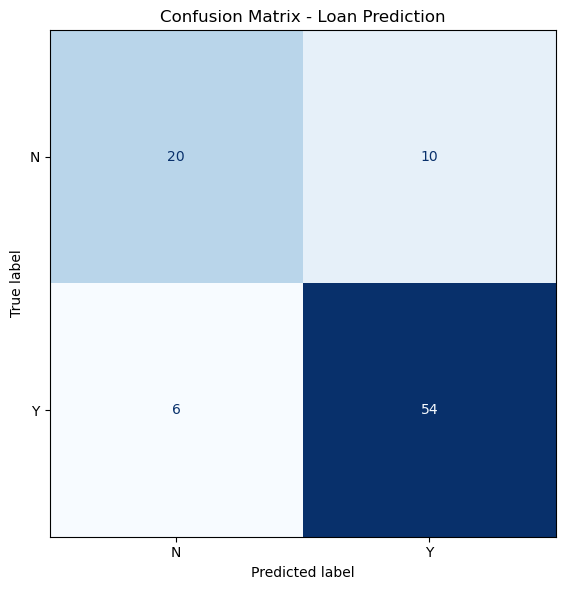

In [46]:
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_estimator(
    pipe, X_test, y_test,
    cmap = 'Blues', ax=ax, colorbar=False,
)
ax.set_title('Confusion Matrix - Loan Prediction')
plt.tight_layout()
plt.show()

#### Cross-Validation

In [47]:
from sklearn.model_selection import cross_val_score
import numpy as np

def cross_validate_model(pipe, X_train, y_train, cv=5):
    """5-fache CV auf den Trainingsdaten; gibt Mittelwert und Streuung aus."""
    try:
        scores = cross_val_score(pipe, X_train, y_train,
                                 cv=cv, scoring='accuracy')
        print(f"CV-Accuracies: {np.round(scores, 4)}")
        print(f"Mittel: {scores.mean():.4f}  Streuung: {scores.std():.4f}")
        return scores
    except (ValueError, KeyError) as e:
        raise ValueError(f'Cross-Validation fehlgeschlagen: {e}') from e

cross_validate_model(pipe, X_train, y_train)

CV-Accuracies: [0.881  0.8095 0.7143 0.8333 0.9048]
Mittel: 0.8286  Streuung: 0.0663


array([0.88095238, 0.80952381, 0.71428571, 0.83333333, 0.9047619 ])

#### Overfitting

In [48]:
def overfitting_momentaufnahme(pipe, X_train, y_train, X_test, y_test):
    """Vergleicht Train- und Test-Accuracy des aktuellen Modells."""
    try:
        train_acc = pipe.score(X_train, y_train)
        test_acc = pipe.score(X_test, y_test)
        print(f"Train-Accuracy: {train_acc:.4f}")
        print(f"Test-Accuracy:  {test_acc:.4f}")
        print(f"Schere:         {train_acc - test_acc:.4f}")
        return train_acc, test_acc
    except (ValueError, AttributeError) as e:
        raise ValueError(f"Momentaufnahme fehlgeschlagen: {e}") from e

overfitting_momentaufnahme(pipe, X_train, y_train, X_test, y_test)

Train-Accuracy: 0.8762
Test-Accuracy:  0.8222
Schere:         0.0540


(0.8761904761904762, 0.8222222222222222)

In [49]:
from sklearn.model_selection import GridSearchCV

def run_grid_search(pipe: Pipeline, X_tr, y_tr, cv: int = 5) -> GridSearchCV:
    """Sucht die beste Hyperparameter-Kombination per Cross-Validation."""
    try:
        param_grid = {
            'tree__criterion': ['entropy', 'gini'],
            'tree__max_depth': [1, 2, 3, 4, 5, None],
            'tree__min_samples_leaf': [1, 5, 10, 20],
        }
        grid = GridSearchCV(
            estimator=pipe,          # unser bestehendes pipe
            param_grid=param_grid,
            cv=cv,                   # StratifiedKFold bei Klassifikation
            scoring='accuracy',
            n_jobs=-1,               # alle CPU-Kerne nutzen
            return_train_score=True,
        )
        grid.fit(X_tr, y_tr)
        return grid
    except (ValueError, KeyError) as e:
        raise ValueError(f'GridSearch fehlgeschlagen: {e}') from e

grid = run_grid_search(pipe, X_train, y_train)

In [50]:
def evaluate_best(grid: GridSearchCV, X_te, y_te) -> None:
    """Bewertet das beste Modell auf dem zurueckgehaltenen Testset."""
    try:
        best = grid.best_estimator_
        y_pred_best = best.predict(X_te)
        print('Beste Parameter :', grid.best_params_)
        print(f'Bester CV-Score : {grid.best_score_:.4f}')
        print(f'Test-Accuracy   : {accuracy_score(y_te, y_pred_best):.4f}\n')
        print(classification_report(y_te, y_pred_best))
    except (ValueError, KeyError) as e:
        raise ValueError(f'Evaluation fehlgeschlagen: {e}') from e

evaluate_best(grid, X_test, y_test)

Beste Parameter : {'tree__criterion': 'entropy', 'tree__max_depth': 1, 'tree__min_samples_leaf': 1}
Bester CV-Score : 0.8476
Test-Accuracy   : 0.8333

              precision    recall  f1-score   support

           N       0.80      0.67      0.73        30
           Y       0.85      0.92      0.88        60

    accuracy                           0.83        90
   macro avg       0.82      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90



In [51]:
try:
    print(grid.best_estimator_)
    print("Beste Parameter:", grid.best_params_)
except NameError:
    print("grid existiert nicht (mehr) - GridSearch-Zelle erneut ausfuehren.")

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dependents',
                                                  OrdinalEncoder(categories=[['0',
                                                                              '1',
                                                                              '2',
                                                                              '3+']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                               

### Baum-Visualisierung mit echten Daten

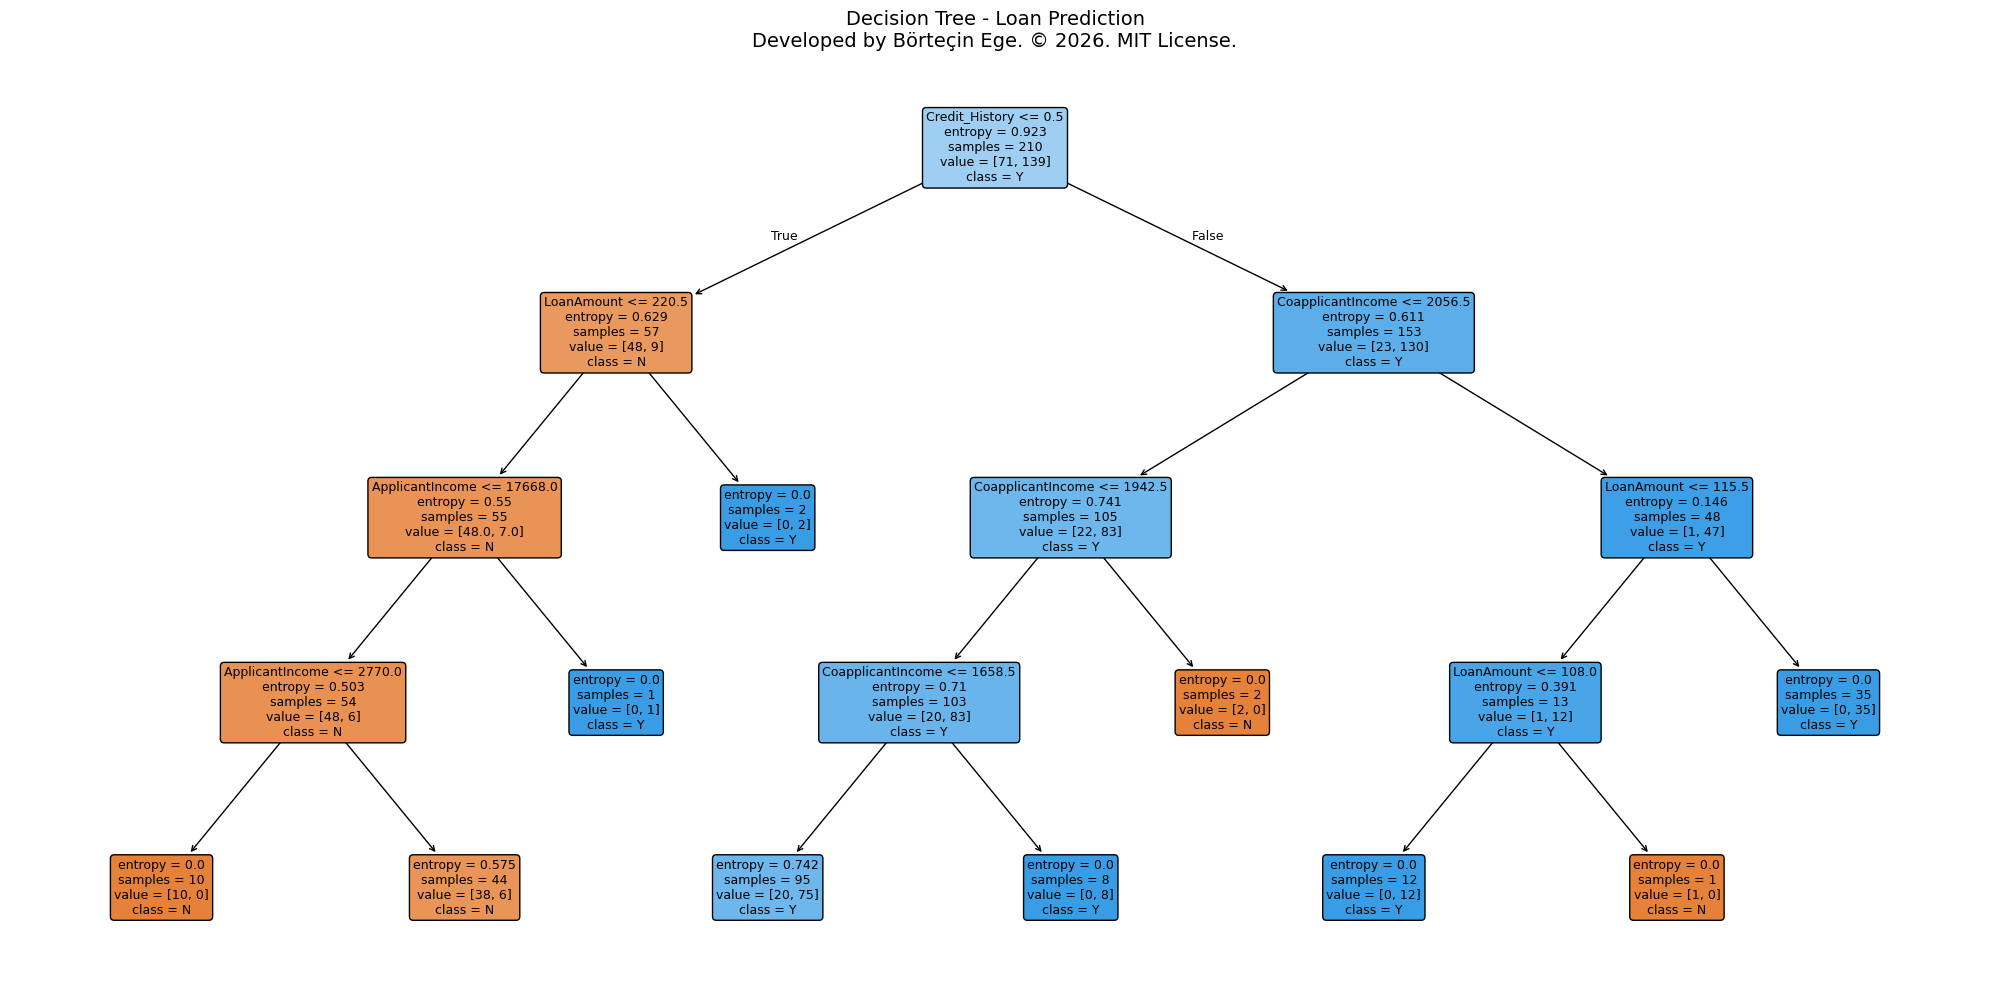

In [52]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def visualisiere_baum(pipe: Pipeline, figsize=(20, 10)):
    """Zeichnet den trainierten Baum aus der Pipeline mit lesbaren Namen.

    Erwartet ein bereits gefittetes pipe mit Schritten 'prep' und 'tree'.
    """
    try:
        tree = pipe.named_steps['tree']
        feature_names = list(pipe.named_steps['prep'].get_feature_names_out())
        class_names = [str(c) for c in tree.classes_]

        fig, ax = plt.subplots(figsize=figsize)
        plot_tree(
            tree,
            feature_names=feature_names,
            class_names=class_names,
            filled=True,        # Farbe = Mehrheitsklasse je Knoten
            rounded=True,
            impurity=True,      # zeigt die Entropie je Knoten
            fontsize=9,
            ax=ax,
        )
        ax.set_title(
            "Decision Tree - Loan Prediction\n"
            "Developed by Börteçin Ege. © 2026. MIT License.",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()
    except (KeyError, ValueError) as e:
        raise ValueError(f'Baum-Visualisierung fehlgeschlagen: {e}') from e

visualisiere_baum(pipe)

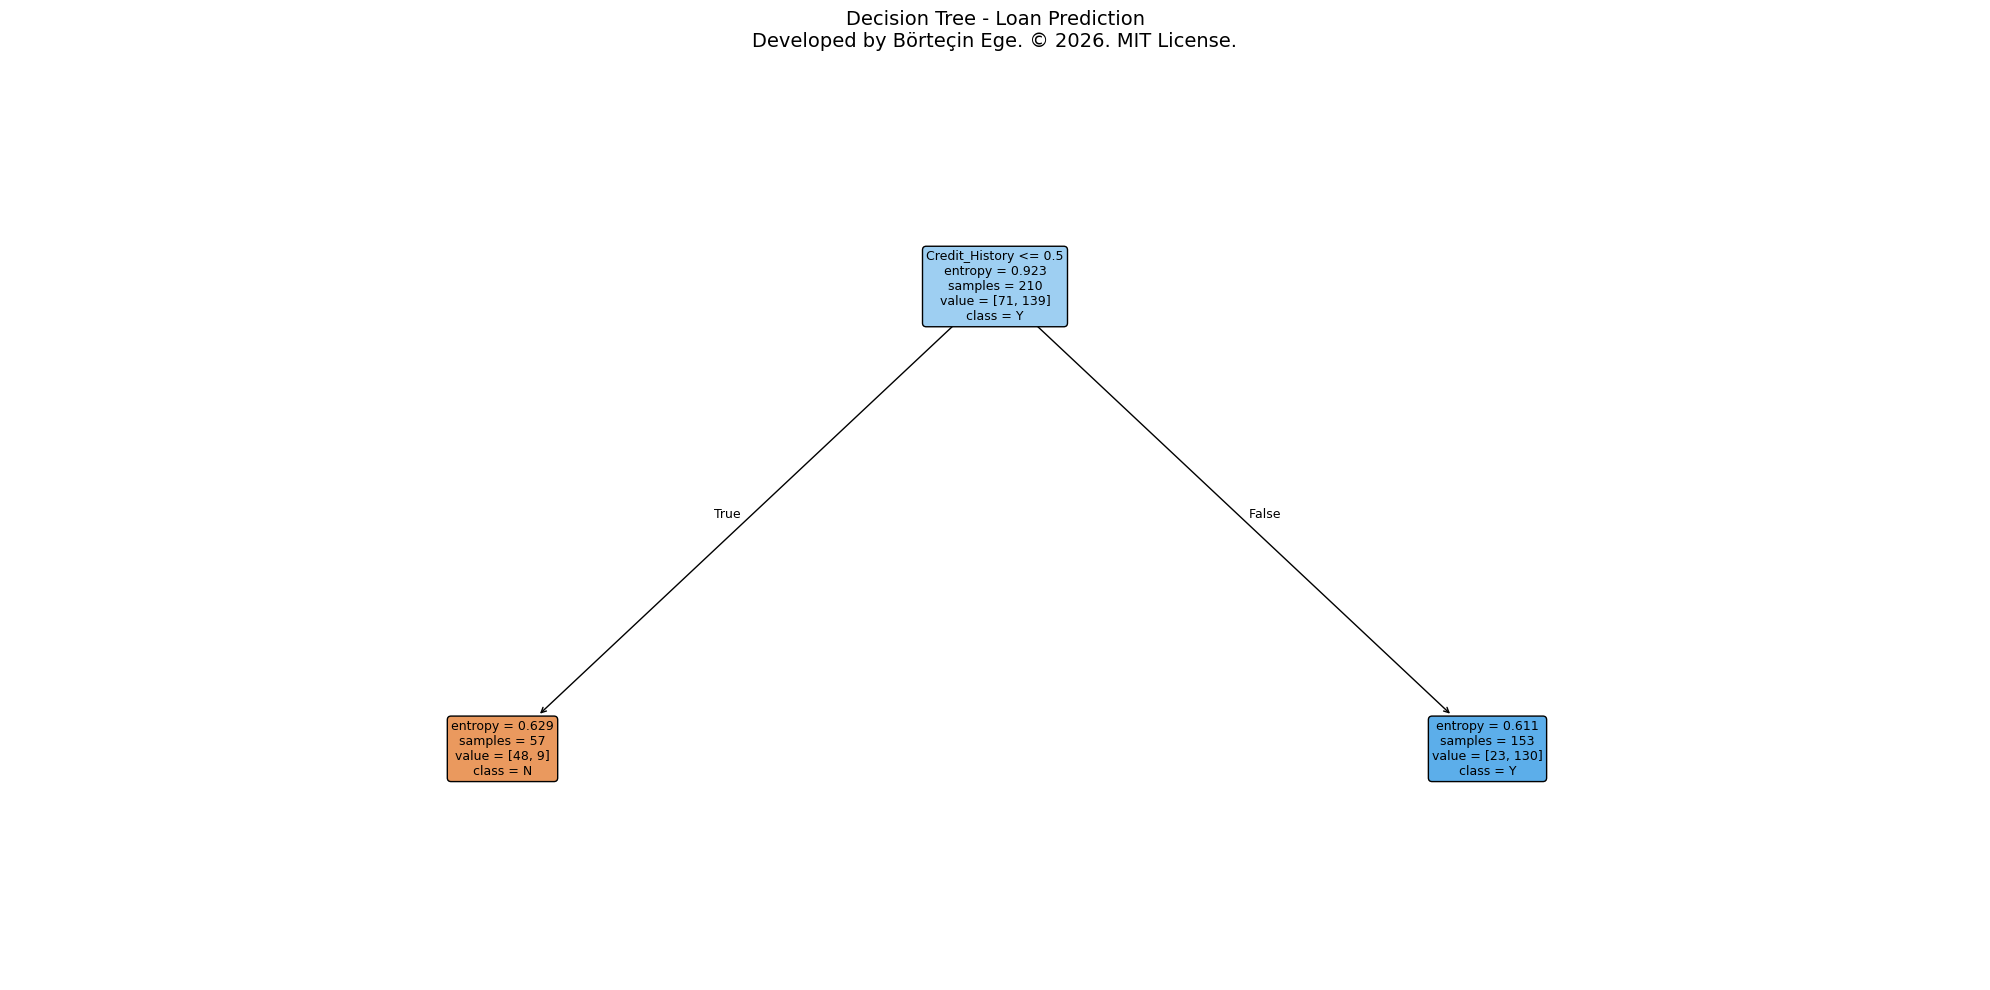

In [53]:
visualisiere_baum(grid.best_estimator_)   # der optimierte Baum (max_depth=1)

#### Inferenz für einen neuen Kunden

In [54]:
import pandas as pd

def pruefe_kunde(pipe: Pipeline, kunde: dict) -> dict:
    """Entscheidet fuer einen neuen Kunden: kreditwuerdig (Y) oder nicht (N).

    Args:
        pipe: trainierte Pipeline (z. B. grid.best_estimator_).
        kunde: dict mit genau den FEATURES-Spalten als Schluessel.

    Returns:
        dict mit Entscheidung und Wahrscheinlichkeiten.
    """
    try:
        fehlend = [c for c in FEATURES if c not in kunde]
        if fehlend:
            raise ValueError(f'Fehlende Merkmale: {fehlend}')

        X_neu = pd.DataFrame([kunde])[FEATURES]

        vorhersage = pipe.predict(X_neu)[0]
        proba = pipe.predict_proba(X_neu)[0]
        klassen = pipe.named_steps['tree'].classes_

        wahrscheinlichkeiten = {str(k): round(float(p), 3)
                                for k, p in zip(klassen, proba)}
        return {
            'entscheidung': str(vorhersage),
            'kreditwuerdig': bool(vorhersage == 'Y'),
            'wahrscheinlichkeiten': wahrscheinlichkeiten,
        }
    except (ValueError, KeyError) as e:
        raise ValueError(f'Kundenpruefung fehlgeschlagen: {e}') from e


neuer_kunde = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': '1',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 1500,
    'LoanAmount': 130,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Property_Area': 'Urban',
}

ergebnis = pruefe_kunde(grid.best_estimator_, neuer_kunde)
print(ergebnis)

{'entscheidung': 'Y', 'kreditwuerdig': True, 'wahrscheinlichkeiten': {'N': 0.15, 'Y': 0.85}}


In [55]:
def vergleiche_modelle(modelle: dict, kunde: dict) -> pd.DataFrame:
    """Fragt mehrere Modelle fuer denselben Kunden ab und stellt sie gegenueber.

    Args:
        modelle: dict {Bezeichnung: trainierte Pipeline}.
        kunde:   dict mit den FEATURES als Schluessel.
    """
    try:
        zeilen = []
        for name, modell in modelle.items():
            r = pruefe_kunde(modell, kunde)
            zeilen.append({
                'Modell': name,
                'Entscheidung': r['entscheidung'],
                **{f'P({k})': v for k, v in r['wahrscheinlichkeiten'].items()},
            })
        return pd.DataFrame(zeilen)
    except (ValueError, KeyError) as e:
        raise ValueError(f'Modellvergleich fehlgeschlagen: {e}') from e

vergleiche_modelle(
    {'Tiefe 4 (pipe)': pipe,
     'Tiefe 1 (best)': grid.best_estimator_},
    neuer_kunde,
)

,Modell,Entscheidung,P(N),P(Y)
0,Tiefe 4 (pipe),Y,0.211,0.789
1,Tiefe 1 (best),Y,0.150,0.850


In [56]:
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

def sicherstellen_gefittet(pipe: Pipeline, X_train, y_train) -> Pipeline:
    """Gibt ein garantiert trainiertes pipe zurueck; fittet nur, falls noetig."""
    try:
        check_is_fitted(pipe.named_steps['tree'])   # wirft NotFittedError, wenn ungefittet
        return pipe                                  # schon trainiert -> unveraendert
    except NotFittedError:
        print('pipe war ungefittet -> wird neu trainiert.')
        return pipe.fit(X_train, y_train)
    except (KeyError, AttributeError) as e:
        raise ValueError(f'Fit-Pruefung fehlgeschlagen: {e}') from e

pipe = sicherstellen_gefittet(pipe, X_train, y_train)
ergebnis = pruefe_kunde(pipe, neuer_kunde)

In [57]:
def vergleiche_modelle(modelle: dict, kunde: dict) -> pd.DataFrame:
    """Fragt mehrere Modelle fuer denselben Kunden ab und stellt sie gegenueber.

    Args:
        modelle: dict {Bezeichnung: trainierte Pipeline}.
        kunde:   dict mit den FEATURES als Schluessel.
    """
    try:
        zeilen = []
        for name, modell in modelle.items():
            r = pruefe_kunde(modell, kunde)
            zeilen.append({
                'Modell': name,
                'Entscheidung': r['entscheidung'],
                **{f'P({k})': v for k, v in r['wahrscheinlichkeiten'].items()},
            })
        return pd.DataFrame(zeilen)
    except (ValueError, KeyError) as e:
        raise ValueError(f'Modellvergleich fehlgeschlagen: {e}') from e

vergleiche_modelle(
    {'Tiefe 4 (pipe)': pipe,
     'Tiefe 1 (best)': grid.best_estimator_},
    neuer_kunde,
)

,Modell,Entscheidung,P(N),P(Y)
0,Tiefe 4 (pipe),Y,0.211,0.789
1,Tiefe 1 (best),Y,0.150,0.850


In [58]:
import ipywidgets as w
from IPython.display import display, clear_output

def baue_kunden_formular(modelle: dict):
    """Interaktives Formular zur Kreditwuerdigkeits-Abfrage in Jupyter Lab.

    Args:
        modelle: dict {Bezeichnung: trainierte Pipeline},
                 z. B. {'Tiefe 4': pipe, 'Tiefe 1 (best)': grid.best_estimator_}.
    """
    try:
        if not modelle:
            raise ValueError('Kein Modell uebergeben.')

        felder = {
            'Gender':            w.Dropdown(options=['Male', 'Female'], description='Gender'),
            'Married':           w.Dropdown(options=['Yes', 'No'], description='Married'),
            'Dependents':        w.Dropdown(options=['0', '1', '2', '3+'], description='Dependents'),
            'Education':         w.Dropdown(options=['Graduate', 'Not Graduate'], description='Education'),
            'Self_Employed':     w.Dropdown(options=['No', 'Yes'], description='Self_Empl.'),
            'ApplicantIncome':   w.IntText(value=5000, description='AppIncome'),
            'CoapplicantIncome': w.IntText(value=1500, description='CoappInc.'),
            'LoanAmount':        w.IntText(value=130, description='LoanAmount'),
            'Loan_Amount_Term':  w.Dropdown(options=[360, 240, 180, 120], description='Term'),
            'Credit_History':    w.Dropdown(options=[('Ja (1)', 1), ('Nein (0)', 0)], description='Credit_Hist'),
            'Property_Area':     w.Dropdown(options=['Urban', 'Semiurban', 'Rural'], description='Property'),
        }
        modell_wahl = w.Dropdown(options=list(modelle.keys()), description='Modell')
        button = w.Button(description='Kreditwuerdigkeit pruefen',
                          button_style='primary', icon='check')
        ausgabe = w.Output()

        def bei_klick(_):
            with ausgabe:
                clear_output()
                try:
                    kunde = {name: feld.value for name, feld in felder.items()}
                    modell = modelle[modell_wahl.value]
                    r = pruefe_kunde(modell, kunde)          # die bestehende Funktion

                    symbol = '✅ KREDITWUERDIG' if r['kreditwuerdig'] else '❌ NICHT kreditwuerdig'
                    print(f'Modell: {modell_wahl.value}')
                    print(f'Entscheidung: {r["entscheidung"]}  ->  {symbol}')
                    print('Wahrscheinlichkeiten:')
                    for klasse, p in r['wahrscheinlichkeiten'].items():
                        print(f'   P({klasse}) = {p:.3f}')
                except (ValueError, KeyError) as e:
                    print(f'Fehler bei der Abfrage: {e}')

        button.on_click(bei_klick)

        display(w.VBox([*felder.values(), modell_wahl, button, ausgabe]))
    except (ValueError, KeyError, AttributeError) as e:
        raise ValueError(f'Formular-Aufbau fehlgeschlagen: {e}') from e


baue_kunden_formular({'Tiefe 4 (pipe)': pipe, 'Tiefe 1 (best)': grid.best_estimator_})

In [59]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def speichere_baum(pipe, dateiname='decision_tree.png', dpi=150):
    """Zeichnet den Baum aus der Pipeline und speichert ihn als Bilddatei.

    Args:
        pipe: trainierte Pipeline mit Schritten 'prep' und 'tree'.
        dateiname: Zielname (.jpg, .jpeg oder .png).
        dpi: Auflösung (höher = schärfer, größere Datei).
    """
    try:
        tree = pipe.named_steps['tree']
        feature_names = list(pipe.named_steps['prep'].get_feature_names_out())
        class_names = [str(c) for c in tree.classes_]

        fig, ax = plt.subplots(figsize=(20, 10))
        plot_tree(tree, feature_names=feature_names, class_names=class_names,
                  filled=True, rounded=True, fontsize=9, ax=ax)
        ax.set_title(
            "Decision Tree - Loan Prediction\n"
            "Developed by Börteçin Ege. © 2026. MIT License.",
            fontsize=14
        )

        fig.savefig(dateiname,
                    dpi=dpi,
                    facecolor='white',      # weißer Hintergrund, unabhängig vom Notebook-Theme
                    bbox_inches='tight')     # schneidet Rand sauber ab
        plt.close(fig)                       # gibt Speicher frei
        print(f'Gespeichert als: {dateiname}')
    except (KeyError, ValueError, OSError) as e:
        raise ValueError(f'Speichern fehlgeschlagen: {e}') from e

speichere_baum(pipe, 'decision_tree.png', dpi=150)   # pipe = dein Tiefe-4-Baum

Gespeichert als: decision_tree.png


#### png vs jpg

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def speichere_confusion(pipe, X_test, y_test, dateiname='confusion_matrix.png', dpi=150):
    """Zeichnet die Confusion Matrix aus der Pipeline und speichert sie als Bild.

    Args:
        pipe: trainierte Pipeline.
        X_test, y_test: Testdaten und wahre Labels.
        dateiname: Zielname (.png empfohlen).
        dpi: Auflösung.
    """
    try:
        labels = sorted(y_test.unique())
        fig, ax = plt.subplots(figsize=(7, 6))
        ConfusionMatrixDisplay.from_estimator(
            pipe, X_test, y_test, labels=labels,
            cmap='Blues', colorbar=False, ax=ax)
        ax.set_title(
            "Confusion Matrix - Loan Prediction\n"
            "Developed by Börteçin Ege. © 2026. MIT License.",
            fontsize=13)
        fig.savefig(dateiname, dpi=dpi, facecolor='white', bbox_inches='tight')
        plt.close(fig)
        print(f'Gespeichert als: {dateiname}')
    except (KeyError, ValueError, OSError) as e:
        raise ValueError(f'Speichern fehlgeschlagen: {e}') from e

speichere_confusion(pipe, X_test, y_test, 'confusion_matrix.png')

Gespeichert als: confusion_matrix.png


### ROC-AUC

In [61]:
from sklearn.metrics import roc_auc_score, roc_curve 

In [62]:
y_prob = pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7861111111111111


In [63]:
print(pipe.classes_)

['N' 'Y']


### ROC-Kurve zusätzlich zeichnen

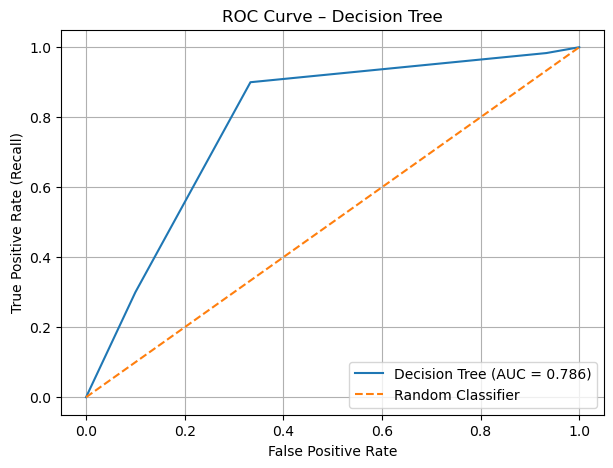

In [64]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Y')

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve – Decision Tree')
plt.legend()
plt.grid()

plt.show()

### Feature Importance

In [65]:

try:
    tree = pipe.named_steps['tree']
    prep = pipe.named_steps['prep']

    feature_names = prep.get_feature_names_out()
    importances = tree.feature_importances_

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    feature_importance.reset_index(drop=True, inplace=True)

except (KeyError, AttributeError, ValueError) as e:
    raise ValueError(f'Feature Importance konnte nicht berechnet werden: {e}') from e

In [66]:
feature_importance

,Feature,Importance
0,Credit_History,0.658415
1,CoapplicantIncome,0.162048
2,LoanAmount,0.128916
3,ApplicantIncome,0.050620
4,Dependents,0.000000
5,Gender_Male,0.000000
6,Married_Yes,0.000000
7,Education_Not Graduate,0.000000
8,Self_Employed_Yes,0.000000
9,Property_Area_Rural,0.000000


### EOF